In [1]:
import json
from pathlib import Path

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_jsonl(filepath):
    data = []

    with open(filepath, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip():
                data.append(json.loads(line))

    return data

In [3]:
checkpoint_dir = Path("data") / "ch09"

In [4]:
#epoches, steps = [], []
#train_losses, val_losses = [], []
#learning_rates, created_at = [], []

records = []

json_files = sorted(
    checkpoint_dir.glob("checkpoint_*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    #tags = f.name.replace("checkpoint_", "").replace(".json", "").split("-", 1)
    #epoch, step = int(tags[0]), int(tags[1])
    records.append((
        data['epoch'], data['step'], data['train_loss'], data['val_loss'],
        data['learning_rate'], data['created_at']),
    )

In [5]:
#df = pd.DataFrame({
#    "epoch": epoches,
#    "step": steps,
#    "train_loss": train_losses,
#    "val_loss": val_losses,
#    "learning_rate": learning_rates,
#    "created_at": created_at,
#})

columns=["epoch", "step", "train_loss", "val_loss", "learning_rate", "created_at"]
df = pd.DataFrame.from_records(records, columns=columns)

df = df.sort_values(by='step', ascending=True)
df.to_csv(checkpoint_dir / "training.tsv", index=False, sep='\t')

In [6]:
#print(df.nsmallest(1, 'train_loss'))
#pd.concat((df.head(10), df.tail(10)))

df.head(20)

,epoch,step,train_loss,val_loss,learning_rate,created_at
0,1,8000,4.483925,4.491979,0.000038,2025-09-15T14:54:44%:z
1,1,16000,3.664065,3.767551,0.000076,2025-09-15T15:25:50%:z
2,1,24000,3.132821,3.307736,0.000114,2025-09-15T15:56:52%:z
3,1,32000,2.760071,2.984072,0.000152,2025-09-15T16:59:42%:z
4,1,40000,2.548054,2.810270,0.000191,2025-09-15T17:44:57%:z
5,1,48000,2.392028,2.710667,0.000229,2025-09-15T18:16:03%:z
6,1,56000,2.291321,2.651382,0.000267,2025-09-15T18:47:07%:z
7,1,64000,2.167756,2.592231,0.000300,2025-09-15T19:18:20%:z
8,1,72000,2.089280,2.563814,0.000300,2025-09-15T19:49:36%:z
9,1,80000,2.011697,2.533019,0.000299,2025-09-15T20:27:55%:z


In [7]:
df.tail(20)

,epoch,step,train_loss,val_loss,learning_rate,created_at
77,5,592000,1.206721,2.503540,0.000033,2025-09-18T12:54:04%:z
78,5,600000,1.208060,2.498195,0.000032,2025-09-18T13:25:04%:z
79,5,608000,1.207205,2.511076,0.000031,2025-09-18T13:56:08%:z
80,5,616000,1.208947,2.496154,0.000030,2025-09-18T14:27:09%:z
81,5,624000,1.202992,2.520447,0.000030,2025-09-18T14:58:03%:z
82,5,629785,1.203023,2.509601,0.000030,2025-09-18T15:21:04%:z
83,6,632000,1.204352,2.499259,0.000030,2025-09-19T10:37:48%:z
84,6,640000,1.202257,2.504882,0.000030,2025-09-19T11:08:49%:z
85,6,648000,1.201048,2.519093,0.000030,2025-09-19T11:48:08%:z
86,6,656000,1.197432,2.519921,0.000030,2025-09-19T12:19:08%:z


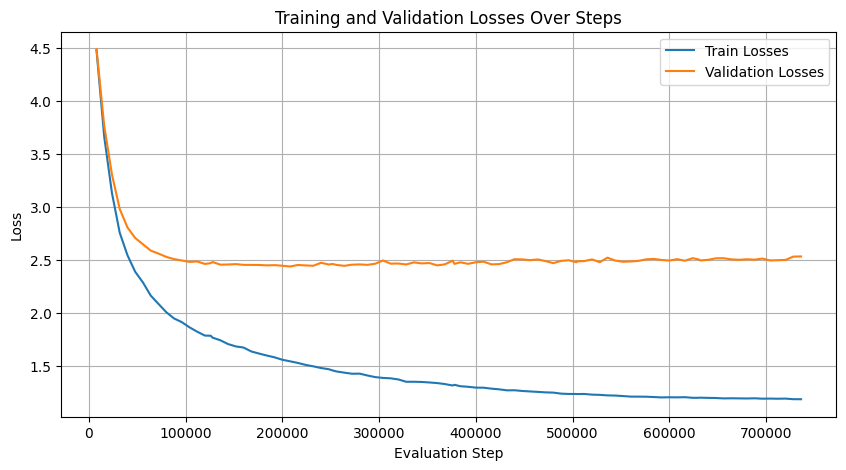

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['train_loss'], label="Train Losses")
plt.plot(df['step'], df['val_loss'], label="Validation Losses")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title("Training and Validation Losses Over Steps")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")

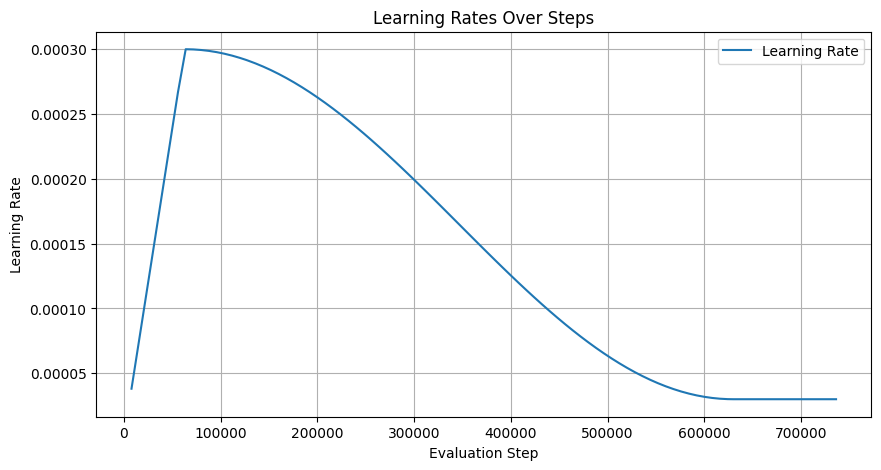

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['learning_rate'], label="Learning Rate")
plt.xlabel("Evaluation Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rates Over Steps")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(checkpoint_dir / "learning_rate.pdf")